 # Assignment 2 2AMM10 2025-2026



 #  ## Group: transformers assemble

 #  ### Member 1: Andrija Hanga

 #  ### Member 2: Ivan Banny

 #  ### Member 3: Neal Ning

In [1]:
import torch
import json
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random
import numpy as np

## Global Variables ##
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
DATA_DIR = "./data"
DROWSY_DATASET_DIR = Path(
    DATA_DIR, "drowsy_graph_dataset"
)  # Path to the drowsy dataset
OBJ_CLS_DATASET_DIR = Path(
    DATA_DIR, "bdd8cls_balanced_300_30"
)  # Path to the object classification dataset
DEVICE = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)

 # Task 1

In [2]:
class DrowsyFaceGraphDataset(Dataset):
    def __init__(self, root, split="train"):
        self.root = Path(root)
        self.split = split

        data_path = self.root / f"{split}.pt"
        class_to_id_path = self.root / "class_to_id.json"
        id_to_class_path = self.root / "id_to_class.json"

        if not data_path.exists():
            raise FileNotFoundError(f"Could not find {data_path}")

        self.graphs = torch.load(data_path, weights_only=False)

        with open(class_to_id_path, "r") as f:
            self.class_to_id = json.load(f)

        with open(id_to_class_path, "r") as f:
            self.id_to_class = json.load(f)

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        return self.graphs[idx]


train_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="train")
test_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="test")
class_to_id: dict = train_dataset.class_to_id
id_to_class: dict = train_dataset.id_to_class



/home/ivan/uni/dl/dl-a2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Axes: >

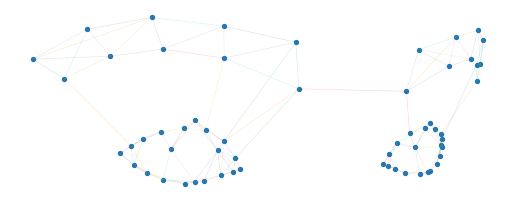

In [3]:
# Visualization helper
def plot_face_graph(
    graph, ax=None, title=None, node_size=8, edge_alpha=0.20, edge_width=0.4
):
    """Plot one face graph using its 2D normalized landmark coordinates."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    coords = graph.x.cpu().numpy()  # Nodes of the Graph
    edge_index = graph.edge_index.cpu().numpy()  # Edges of the Graph

    xy = coords[:, :2]

    seen = set()
    for i, j in edge_index.T:
        a, b = int(i), int(j)
        key = tuple(sorted((a, b)))
        if key in seen:
            continue
        seen.add(key)
        ax.plot(
            [xy[a, 0], xy[b, 0]],
            [xy[a, 1], xy[b, 1]],
            linewidth=edge_width,
            alpha=edge_alpha,
        )

    ax.scatter(xy[:, 0], xy[:, 1], s=node_size)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")

    if title is not None:
        ax.set_title(title)

    return ax


fig, ax = plt.subplots()
idx = random.randint(0, len(train_dataset) - 1)
graph = train_dataset[idx]
x, y = graph.x, graph.y
plot_face_graph(graph, ax)


# Understanding the samples
# 1) graph.x: (Num_nodes, 3) matrix. The coordinates (x1,x2,x3) of the facial landmarks, normalized to [-1,1]. Those are the node features of the graph.
# 2) graph.edge_index: (2, Num_edges) matrix. The edges of the graph, where each column (i,j) represents an edge from node i to node j.
# 3) graph.y: The label of the graph, where 0 means "alert" and 1 means "drowsy". This is the target variable we want to predict.
# 4) You can safely ignore the other 2 attributes of the graph (source_index and eye_openness) for this assignment.
# For completeness, eye_openness is a score in [0,1] that indicates how open the eyes are, and source_index is an index corresponding to the sample index with respect to the original dataset before graph construction.



 ## Task 1: model design



 The task has the following symmetries, which we manifest in our model:



 - **Permutation invariance.** Node order is meaningless - so we use message passing and

   pool the nodes with a symmetric readout; not order-dependent.

 - **Mesh connectivity.** Edges mark adjacent landmarks, information flows only along them.

 - **Translation.** Faces are not centered, so only relative geometry matters - every

   message is built from the offset `pos_j - pos_i`.



 400 graphs is embarrassing, so overfitting is the main risk - we keep the model small and

 regularize hard: geometric augmentation, dropout, weight decay, node dropout, and early

 stopping on a validation split. The test set is touched once, at the end. Three additional

 improvements: an edge-length feature, a seed ensemble, and a recall-tuned decision threshold.

In [4]:
import torch.nn.functional as F
from torch.optim import AdamW
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import MessagePassing, global_max_pool, global_mean_pool

drowsy_train = train_dataset
drowsy_test = test_dataset


def stratified_split(graphs, val_frac=0.2, seed=42):
    """Split graphs into (train, val), keeping the class balance in both halves.

    Checkpoint and threshold selection run on the validation set, so test stays untouched
    until the final report.
    """
    labels = np.array([int(g.y) for g in graphs])
    rng = np.random.default_rng(seed)
    train_idx, val_idx = [], []
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        rng.shuffle(idx)
        n_val = int(round(len(idx) * val_frac))
        val_idx.extend(idx[:n_val])
        train_idx.extend(idx[n_val:])
    return [graphs[i] for i in train_idx], [graphs[i] for i in val_idx]


fit_graphs, val_graphs = stratified_split(drowsy_train.graphs, val_frac=0.2, seed=42)
print(
    f"split - fit {len(fit_graphs)} - val {len(val_graphs)} - test {len(drowsy_test.graphs)}"
)



split - fit 320 - val 80 - test 100


In [5]:
def augment_graph(
    data,
    rot=0.2,
    scale=0.1,
    trans=0.05,
    jitter=0.01,
    node_drop=0.1,
):
    """Return a label-preserving geometric perturbation of a face graph."""
    g = data.clone()
    x = g.x

    # Small 3d rotation, composed from three per-axis turns
    a = (torch.rand(3) * 2 - 1) * rot
    cx, cy, cz = torch.cos(a)
    sx, sy, sz = torch.sin(a)
    rx = torch.tensor([[1, 0, 0], [0, cx, -sx], [0, sx, cx]])
    ry = torch.tensor([[cy, 0, sy], [0, 1, 0], [-sy, 0, cy]])
    rz = torch.tensor([[cz, -sz, 0], [sz, cz, 0], [0, 0, 1]])
    x = x @ (rz @ ry @ rx).T

    # Isotropic scale, global translation, then per-coordinate jitter
    x = x * (1 + (torch.rand(1) * 2 - 1) * scale)
    x = x + (torch.rand(3) * 2 - 1) * trans
    x = x + torch.randn_like(x) * jitter

    # Node dropout
    mask = torch.rand(x.size(0)) < node_drop
    x[mask] = 0.0

    g.x = x
    return g


class AugmentedGraphDataset(Dataset):
    """Apply augment_graph on the fly - identity when augment is None."""

    def __init__(self, graphs, augment=None):
        self.graphs = graphs
        self.augment = augment

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        g = self.graphs[idx]
        return self.augment(g) if self.augment is not None else g



In [6]:
class FaceMPLayer(MessagePassing):
    """One message-passing step over the face mesh.

    We write message / aggregate / update ourselves, using PyG only for scatter
    plumbing. A message depends on both endpoint states and their relative position,
    which makes the layer translation-invariant. Aggregation is a neighbor mean -
    permutation-invariant - and the update is a residual MLP with norm.
    """

    def __init__(self, hidden, dropout):
        super().__init__(aggr="mean")
        # Message input - both endpoint states, the offset (3) and its length (1)
        # The offset is rotation-equivariant; the length is rotation-invariant
        self.msg_mlp = nn.Sequential(
            nn.Linear(2 * hidden + 4, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
        )
        self.upd_mlp = nn.Sequential(
            nn.Linear(2 * hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
        )
        self.norm = nn.LayerNorm(hidden)
        self.drop = nn.Dropout(dropout)

    def forward(self, h, pos, edge_index):
        return self.propagate(edge_index, h=h, pos=pos)

    def message(self, h_i, h_j, pos_i, pos_j):
        # Offset survives translation of the face, its norm survives rotation too
        rel = pos_j - pos_i
        dist = rel.norm(dim=-1, keepdim=True)
        return self.msg_mlp(torch.cat([h_i, h_j, rel, dist], dim=-1))

    def update(self, aggr_out, h, pos):
        out = self.upd_mlp(torch.cat([h, aggr_out], dim=-1))
        # Residual, then normalize for stability
        return self.norm(h + self.drop(out))


class DrowsyGNN(nn.Module):
    """Message-passing classifier - lift coords, pass messages, pool, linear head.
    Copyright (c) 2026 Ivanics Questionable Science Ivannovations Laboratories Unlimited.

    The readout concatenates mean- and max-pool over nodes, both permutation-invariant.
    This way - one noisy landmark cannot decide the outcome, but a strongly drowsy
    region still shows in the max. The head emits one logit, drowsy as positive.
    """

    def __init__(self, hidden=64, num_layers=3, dropout=0.3):
        super().__init__()
        self.encoder = nn.Linear(3, hidden)
        self.layers = nn.ModuleList(
            [FaceMPLayer(hidden, dropout) for _ in range(num_layers)]
        )
        self.head = nn.Sequential(
            nn.Linear(2 * hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

        self.apply(self._init_weights)
        for layer in self.layers:
            nn.init.normal_(layer.upd_mlp[-1].weight, std=1e-3)
            nn.init.zeros_(layer.upd_mlp[-1].bias)
        nn.init.normal_(self.head[-1].weight, std=1e-3)
        nn.init.zeros_(self.head[-1].bias)

    @staticmethod
    def _init_weights(module):
        # He init, zero bias - every linear feeds a ReLU
        if isinstance(module, nn.Linear):
            nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, data):
        pos = data.x
        h = self.encoder(pos)
        for layer in self.layers:
            h = layer(h, pos, data.edge_index)

        # Permutation-invariant readout - mean and max over each graph's nodes
        g = torch.cat(
            [global_mean_pool(h, data.batch), global_max_pool(h, data.batch)], dim=-1
        )
        return self.head(g).squeeze(-1)



In [7]:
@torch.no_grad()
def predict_logits(model, loader):
    """Return (logits, labels) for the drowsy class over a loader."""
    model.eval()
    logits, labels = [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        logits.append(model(batch).cpu())
        labels.append(batch.y.cpu().float())
    return torch.cat(logits), torch.cat(labels)


def bce_loss(model, loader):
    """BCE-with-logits loss of a single model over a loader."""
    logits, labels = predict_logits(model, loader)
    return F.binary_cross_entropy_with_logits(logits, labels).item()


def ensemble_probs(models, loader):
    """Average the drowsy-probabilities of several models over a loader."""
    probs, labels = None, None
    for model in models:
        logits, labels = predict_logits(model, loader)
        p = torch.sigmoid(logits)
        probs = p if probs is None else probs + p
    return probs / len(models), labels


def precision_recall(probs, labels, threshold):
    """Precision and recall for the drowsy class at a probability threshold.

    Recall = TP / (TP + FN), the fraction of drowsy drivers we catch; precision =
    TP / (TP + FP), the fraction of drowsy calls that are right. FN is the
    dangerous error, so recall is what we optimize for.
    """
    pred = (probs >= threshold).float()
    tp = ((pred == 1) & (labels == 1)).sum().item()
    fp = ((pred == 1) & (labels == 0)).sum().item()
    fn = ((pred == 0) & (labels == 1)).sum().item()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return precision, recall


def tune_threshold(probs, labels, min_precision=0.6):
    """Pick the threshold with the highest recall that still keeps precision >= min_precision.

    We sweep every observed probability as a cut and; among those above the
    precision floor - take the best recall. If none clear the floor - fall back to 0.5.
    """
    candidates = torch.cat([torch.zeros(1), torch.sort(probs).values, torch.ones(1)])
    best_key, best_threshold = None, 0.5
    for t in candidates.tolist():
        precision, recall = precision_recall(probs, labels, t)
        if precision >= min_precision:
            key = (recall, precision)
            if best_key is None or key > best_key:
                best_key, best_threshold = key, t
    return best_threshold



In [8]:
BATCH_SIZE = 32
EPOCHS = 150
SEEDS = [0, 1, 2, 3, 4]

# Loaders are shared across seeds - the augmented fit stream is shuffled, val and test are
# fixed order. Only the init and shuffle order depend on the seed
fit_loader = GeoDataLoader(
    AugmentedGraphDataset(fit_graphs, augment=augment_graph),
    batch_size=BATCH_SIZE,
    shuffle=True,
)
fit_eval_loader = GeoDataLoader(
    AugmentedGraphDataset(fit_graphs), batch_size=BATCH_SIZE
)
val_loader = GeoDataLoader(AugmentedGraphDataset(val_graphs), batch_size=BATCH_SIZE)
test_loader = GeoDataLoader(
    AugmentedGraphDataset(drowsy_test.graphs), batch_size=BATCH_SIZE
)


def train_model(seed):
    """Train one model and return it at its best validation checkpoint, with its loss history.

    Selection uses min(precision, recall) on validation. Test loss is logged each epoch
    for the curves, not used to choose anything.
    """
    torch.manual_seed(seed)
    model = DrowsyGNN(hidden=64, num_layers=3, dropout=0.3).to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

    history = {"train_loss": [], "test_loss": []}
    best_score, best_state = (-1.0, -float("inf")), None
    for _ in range(EPOCHS):
        model.train()
        for batch in fit_loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            loss = F.binary_cross_entropy_with_logits(model(batch), batch.y.float())
            loss.backward()
            optimizer.step()

        history["train_loss"].append(bce_loss(model, fit_eval_loader))
        history["test_loss"].append(bce_loss(model, test_loader))

        val_logits, val_labels = predict_logits(model, val_loader)
        val_prec, val_rec = precision_recall(torch.sigmoid(val_logits), val_labels, 0.5)
        val_loss = F.binary_cross_entropy_with_logits(val_logits, val_labels).item()
        score = (min(val_prec, val_rec), -val_loss)
        if score > best_score:
            best_score = score
            best_state = {
                k: v.detach().cpu().clone() for k, v in model.state_dict().items()
            }

    model.load_state_dict(best_state)
    return model, history



In [9]:
models, histories = [], []
for seed in SEEDS:
    model, history = train_model(seed)
    models.append(model)
    histories.append(history)

    val_logits, val_labels = predict_logits(model, val_loader)
    vp, vr = precision_recall(torch.sigmoid(val_logits), val_labels, 0.5)
    print(f"seed {seed} - val precision {vp:.3f} - val recall {vr:.3f}")
print(f"\ntrained an ensemble of {len(models)} models")


/home/ivan/uni/dl/dl-a2/.venv/lib/python3.13/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


seed 0 - val precision 0.947 - val recall 0.900
seed 1 - val precision 0.923 - val recall 0.900
seed 2 - val precision 0.972 - val recall 0.875
seed 3 - val precision 1.000 - val recall 0.900
seed 4 - val precision 0.878 - val recall 0.900

trained an ensemble of 5 models


In [10]:
# Calibrate the operating point on validation, then freeze it
val_probs, val_labels = ensemble_probs(models, val_loader)
threshold = tune_threshold(val_probs, val_labels, min_precision=0.6)
val_prec, val_rec = precision_recall(val_probs, val_labels, threshold)
print(
    f"tuned threshold {threshold:.3f} - val precision {val_prec:.3f} - val recall {val_rec:.3f}"
)


tuned threshold 0.318 - val precision 0.844 - val recall 0.950


 ### Task 1: training and test loss curves



 Curves averaged over the ensemble's seeds.

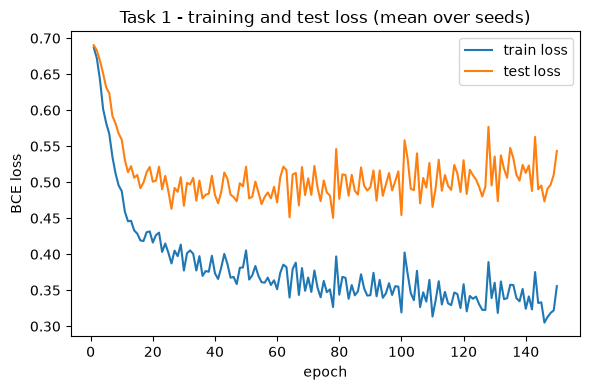

In [11]:
train_curve = np.mean([h["train_loss"] for h in histories], axis=0)
test_curve = np.mean([h["test_loss"] for h in histories], axis=0)

fig, ax = plt.subplots(figsize=(6, 4))
epochs_axis = range(1, EPOCHS + 1)
ax.plot(epochs_axis, train_curve, label="train loss")
ax.plot(epochs_axis, test_curve, label="test loss")
ax.set_xlabel("epoch")
ax.set_ylabel("BCE loss")
ax.set_title("Task 1 - training and test loss (mean over seeds)")
ax.legend()
fig.tight_layout()


 ### Task 1: test-set evaluation metrics



 Recall and precision for the drowsy class on the test set - the ensemble at the

 validation-tuned threshold - against the 0.6 baseline.

test precision (drowsy): 0.759
test recall    (drowsy): 0.880


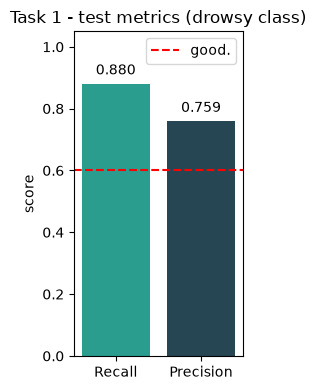

In [17]:
test_probs, test_labels = ensemble_probs(models, test_loader)
test_precision, test_recall = precision_recall(test_probs, test_labels, threshold)
print(f"test precision (drowsy): {test_precision:.3f}")
print(f"test recall    (drowsy): {test_recall:.3f}")

fig, ax = plt.subplots(figsize=(2.5, 4))
bars = ax.bar(
    ["Recall", "Precision"],
    [test_recall, test_precision],
    color=["#2a9d8f", "#264653"],
)
ax.axhline(0.6, color="red", linestyle="--", label="good.")
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("Task 1 - test metrics (drowsy class)")
for bar, val in zip(bars, [test_recall, test_precision]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.02,
        f"{val:.3f}",
        ha="center",
        va="bottom",
    )
ax.legend()
fig.tight_layout()


 # Task 2

In [ ]:
class _BaseImageClassificationDataset(Dataset):
    """
    Base dataset for image classification datasets stored as:

        dataset_dir/
            class_to_id.json
            id_to_class.json
            train/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
            test/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
    """

    def __init__(
        self,
        dataset_dir,
        split="train",
        img_transform=None,
    ):
        super().__init__()
        self.dataset_dir = Path(dataset_dir)
        self.split = split
        self.img_transform = img_transform

        if self.split not in {"train", "test"}:
            raise ValueError(f"split must be 'train' or 'test', got: {self.split}")

        self.split_dir = self.dataset_dir / self.split
        self.labels_path = self.split_dir / "labels.csv"
        self.class_to_id_path = self.dataset_dir / "class_to_id.json"
        self.id_to_class_path = self.dataset_dir / "id_to_class.json"

        if not self.dataset_dir.exists():
            raise FileNotFoundError(f"Dataset directory not found: {self.dataset_dir}")
        if not self.split_dir.exists():
            raise FileNotFoundError(f"Split directory not found: {self.split_dir}")
        if not self.labels_path.exists():
            raise FileNotFoundError(f"labels.csv not found: {self.labels_path}")
        if not self.class_to_id_path.exists():
            raise FileNotFoundError(
                f"class_to_id.json not found: {self.class_to_id_path}"
            )
        if not self.id_to_class_path.exists():
            raise FileNotFoundError(
                f"id_to_class.json not found: {self.id_to_class_path}"
            )

        with open(self.class_to_id_path, "r") as fp:
            self.class_to_id = json.load(fp)

        with open(self.id_to_class_path, "r") as fp:
            self.id_to_class = json.load(fp)

        # Normalize keys for convenience
        self.id_to_class = {int(k): v for k, v in self.id_to_class.items()}
        self.num_classes = len(self.class_to_id)
        self.classes = [self.id_to_class[i] for i in range(self.num_classes)]

        self.labels = (
            pd.read_csv(self.labels_path, header=None).iloc[:, 0].astype(int).tolist()
        )

        self.img_paths = sorted(
            [
                p
                for p in self.split_dir.iterdir()
                if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
            ],
            key=lambda p: p.name,
        )

        if len(self.img_paths) != len(self.labels):
            raise ValueError(
                f"Mismatch between number of images ({len(self.img_paths)}) and "
                f"labels ({len(self.labels)}) in split '{self.split}'."
            )

    def __len__(self):
        return len(self.labels)

    def _load_image(self, img_path):
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.img_transform is not None:
                img = self.img_transform(img)
            return img

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = self._load_image(img_path)
        label = self.labels[idx]

        return image, label


class BDDObjectClassificationDataset(_BaseImageClassificationDataset):
    """
    Dataset for the cropped-object classification dataset.

    Returns:
        image, label
    or:
        image, label, metadata   (if return_metadata=True)

    Notes:
        - img_transform defaults to None.
        - The user is responsible for resizing / tensor conversion.
    """

    pass


class PatchShuffle:
    def __init__(self, patch_size=8):
        self.p = patch_size

    def __call__(self, img):
        # Input: [C, H, W]
        c, h, w = img.shape
        p = self.p

        # 1. Unfold image into patches [C, H/p, W/p, p, p]
        patches = img.unfold(1, p, p).unfold(2, p, p)
        num_h = h // p
        num_w = w // p

        # 2. Reshape to [num_patches, C, p, p]
        patches = patches.contiguous().view(c, -1, p, p).permute(1, 0, 2, 3)

        # 3. Shuffle the patches along the first dimension
        idx = torch.randperm(patches.size(0))
        patches = patches[idx]

        # 4. Reshape back to original image dimensions
        # We need to rearrange from [num_h*num_w, C, p, p] back to [C, H, W]
        patches = patches.view(num_h, num_w, c, p, p).permute(2, 0, 3, 1, 4)
        shuffled_img = patches.contiguous().view(c, h, w)

        return shuffled_img


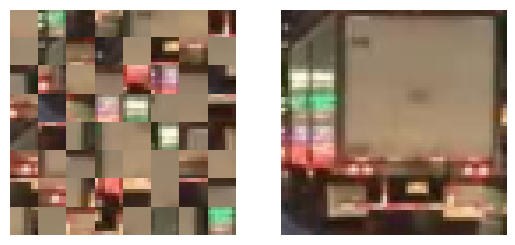

In [3]:
from torchvision.transforms import Compose, ToTensor, Resize
from torchvision.transforms import functional as vf
import matplotlib.pyplot as plt

train_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    # Fill train image transforms: 
    img_transform=Compose([Resize((64,64)), ToTensor()]),
)

test_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    # Fill test image transforms: 
    img_transform=Compose([Resize((64,64)), ToTensor()]),
)

### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###
vis_dataset_noisy = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor(), PatchShuffle(patch_size=8)]),
)
vis_dataset_clean = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor()]),
)
fig, ax = plt.subplots(1, 2)
img_noisy, label = vis_dataset_noisy[16]
img_clean, label = vis_dataset_clean[16]
ax[0].imshow(vf.to_pil_image(img_noisy))
ax[1].imshow(vf.to_pil_image(img_clean))
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_frame_on(False)
### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###


In [4]:
class EmbeddingCNN(nn.Module):
    """
    Split a given 3x64x64 image into 8x8 patches and apply a small CNN model
    over each patches to obtain a flattened embedding of each patch.
    """
    def __init__(self, in_chan=3, emb_dim=128, patch_size=8):
        super().__init__()
        self.in_chan = in_chan 
        self.emb_dim = emb_dim 
        self.patch_size = patch_size
        self.num_patches = patch_size ** 2

        self.pcnn = nn.Sequential(
            nn.Conv2d(in_chan, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Flatten(),
            nn.Linear(64 * self.num_patches, emb_dim)
        )
    
    def forward(self, x):
        ps = self.patch_size
        batches = x.shape[0] # (B, 3, 64, 64)
        # Operations to apply the same CNN params to each patch
        x = x.view(batches, self.in_chan, ps, ps, ps, ps) # (B, 3, 8, 8, 8, 8)
        x = x.permute(0, 2, 4, 1, 3, 5).contiguous() # (B, 8, 8, 3, 8, 8)
        x = x.view(batches * self.num_patches, self.in_chan, ps, ps) # (B*64, 3, 8, 8)
        x = self.pcnn(x) # (B*64, out_chan, 1, 1)
        x = x.view(batches, self.num_patches, self.emb_dim) # (B, 64, out_chan)
        return x


class VIT(nn.Module):
    """
    A ViT model that tokenizes each patch from EmbeddingCNN and pass it through 
    fully connected transformer layers and classify the image.
    """
    def __init__(
            # Model params
            self, 
            in_chan=3,
            emb_dim=128, 
            patch_size=8, 
            n_classes=train_dataset.num_classes, 
            # Transformer params: 
            nhead=4,
            n_layers=2, 
            dim_ff=128,
            dropout=0.3,
        ):
        super().__init__()

        self.patch_emb = EmbeddingCNN(in_chan, emb_dim, patch_size)
        self.final_token = nn.Parameter(torch.zeros(1, 1, emb_dim)) 
        nn.init.trunc_normal_(self.final_token, std=0.02) # Init with small randomness

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(emb_dim)
        self.fc = nn.Linear(emb_dim, n_classes)

    def forward(self, x):
        batches = x.shape[0]
        tokens = self.patch_emb(x)
        final_token = self.final_token.expand(batches, -1, -1)

        tokens = torch.cat([final_token, tokens], dim=1)
        tokens = self.encoder(tokens)

        out = self.fc(self.norm(tokens[:, 0]))
        return out


/tmp/ipykernel_127057/4290999140.py:72: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


epoch 10: train acc - 0.451; test acc - 0.379
epoch 20: train acc - 0.612; test acc - 0.417
epoch 30: train acc - 0.756; test acc - 0.421
epoch 40: train acc - 0.827; test acc - 0.412
epoch 50: train acc - 0.922; test acc - 0.438


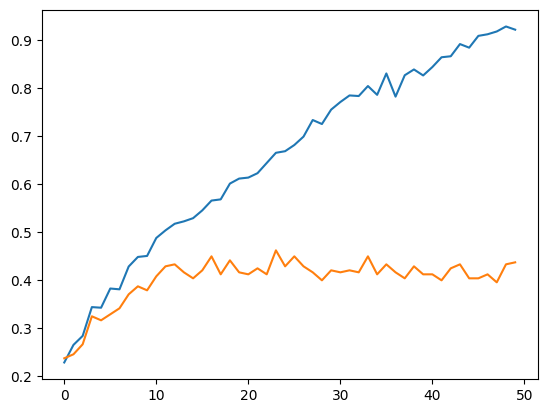

In [6]:
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.optim import AdamW

BATCH_SIZE = 64
EPOCHS = 50

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# === Training Loop === #

@torch.no_grad()
def accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        preds = model(images).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return correct / total

def train_model(seed):
    torch.manual_seed(seed)
    model = VIT().to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    history = {"train_acc": [], "test_acc": []}

    for epoch in range(1, EPOCHS + 1):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = F.cross_entropy(model(images), labels)
            loss.backward()
            optimizer.step()

        train_acc = accuracy(model, train_loader)
        test_acc = accuracy(model, test_loader)

        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        if epoch % 10 == 0: print(f"epoch {epoch}: train acc - {train_acc:.3f}; test acc - {test_acc:.3f}")

    return model, history

model, history = train_model(42)

plt.plot(history["train_acc"])
plt.plot(history["test_acc"])


In [7]:
# === Metric Helpers === # 

@torch.no_grad()
def predict_logits(model, loader):
    """
    Return (logits, labels) for samples in a loader.
    """
    model.eval()
    all_logits, all_labels = [], []
    for images, labels in loader:
        images = images.to(DEVICE)
        all_logits.append(model(images).cpu())
        all_labels.append(labels)
    return torch.cat(all_logits), torch.cat(all_labels)


def compute_metrics(logits, labels, num_classes, agg=False):
    """
    If not agg, then computes precision and recall per class. If agg, then  
    computes aggregated precision and recall values using macro averaging.
    """
    preds = logits.argmax(dim=1)
    precs, recs = [], []
    for c in range(num_classes):
        tp = ((preds == c) & (labels == c)).sum().float()
        fp = ((preds == c) & (labels != c)).sum().float()
        fn = ((preds != c) & (labels == c)).sum().float()
        precs.append((tp / (tp + fp)) if (tp + fp) > 0 else torch.tensor(0.0))
        recs.append((tp / (tp + fn)) if (tp + fn) > 0 else torch.tensor(0.0))
    if agg: 
        return torch.stack(precs).mean().item(), torch.stack(recs).mean().item()
    else: 
        return torch.stack(precs), torch.stack(recs)

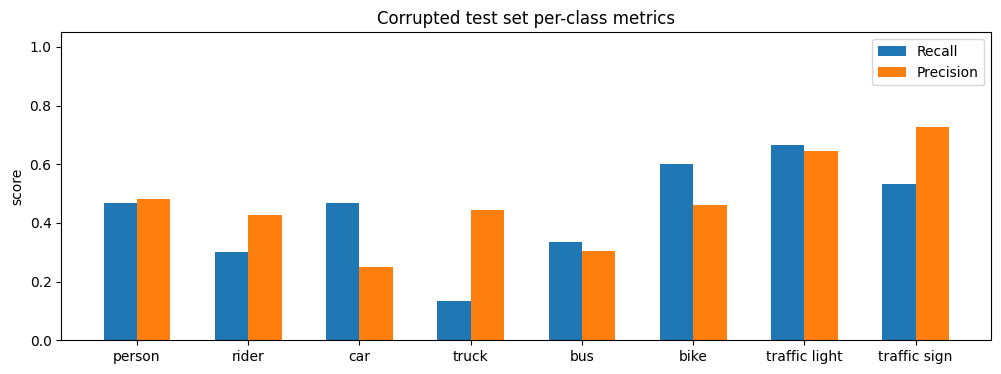

In [8]:
# Construct corrupted test set
test_dataset_corrupted = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor(), PatchShuffle(patch_size=8)]),
)
test_loader_corrupted = DataLoader(test_dataset_corrupted, batch_size=BATCH_SIZE, shuffle=False)

# Compute per class metrics
corrupted_logits, corrupted_labels = predict_logits(model, test_loader_corrupted)
class_precision, class_recall = compute_metrics(
    corrupted_logits, corrupted_labels, train_dataset.num_classes, agg=False
)

# Plot
classes = train_dataset.classes
x = np.arange(len(classes))
width = 0.3

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - width / 2, class_recall.tolist(), width, label="Recall")
ax.bar(x + width / 2, class_precision.tolist(), width, label="Precision")
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("Corrupted test set per-class metrics")
ax.legend();

In [9]:
# Compute macro aggregated metrics

corrupted_precision = class_precision.mean().item()
corrupted_recall = class_recall.mean().item()

clean_logits, clean_labels = predict_logits(model, test_loader)
clean_precision, clean_recall = compute_metrics(clean_logits, clean_labels, train_dataset.num_classes, agg=True)

print(f"corrupted test set: precision = {corrupted_precision:.4f} | recall = {corrupted_recall:.4f}")
print(f"clean test set: precision = {clean_precision:.4f} | recall = {clean_recall:.4f}")

corrupted test set: precision = 0.4678 | recall = 0.4375
clean test set: precision = 0.4678 | recall = 0.4375


 ## Task 3

In [ ]:
# This utility class is aimed to help you a bit with the linear probe classifier.
# You can choose whether to implement it or not!


class LinearProbeClassifier(nn.Module):
    """
    Frozen pretrained backbone + trainable linear classification head.

    TODO:
    - load a pretrained backbone,
    - remove/replace its original classification head (if any),
    - freeze the backbone parameters,
    - add a new trainable linear head for the BDD classes.
    """

    def __init__(self, backbone_arch: str, num_classes: int):
        super().__init__()
        self.backbone = None  # Here you can use a function that creates the backbone model based on the backbone_arch string (take a look here: https://docs.pytorch.org/vision/main/models.html)

        # TODO: Sometimes the pretrained backbone may already have a classification head (e.g. ResNet's fc layer, ViT's heads layer). In this case you might need to replace it with an Identity layer to get the features before the head.
        # The Identity layer is simply a placeholder for the Identity function, which returns its input unchanged.

        # TODO: freeze all pretrained backbone parameters. Freezing a parameter means that it will not be updated during gradient updates.

        # TODO: define the trainable linear classification head
        self.linear_head = None

    def forward(self, x: torch.Tensor):
        # The backbone should be used as a feature extractor.

        # Then the features from the backbone are passed through the linear head to get the final logits for classification.
        pass
